# **Models evaluation**

This notebook file shows the evaluation of the three baseline models: simple classifier tree, classifier tree with a minimax algorithm to improve the quality of the prediction and a random forest model with the minimax algorithm.

### 1 - Models importation

In [9]:
from bot import BaseBot, BaseBot2, BaseBot3, LowEloBot, Stockfish
from engine import Engine

import chess

In [2]:
# Engine class which inherits from the python chess library
engine = Engine()

# Baseline models
classifier = BaseBot(engine)
cl_minimax = BaseBot2(engine)
forest_minimax = BaseBot3(engine)

# Simple random bots which capture pieces when it can
greedy = LowEloBot(engine)

# Stockfish engine
stockfish = Stockfish(engine, elo=200)

### 2 - Training & accuracy

In [3]:
classifier.fit()

Training Accuracy: 71.38%


In [4]:
cl_minimax.fit()

Training Accuracy: 71.38%


In [5]:
forest_minimax.fit()

Training Accuracy: 70.97%


Here we can see that the accuracy is around 71% for all three models. This is explained by the fact that the classification of good or bad for a move is simply based on the material difference of a given position and other simple features. This cannot represent a quality prediction because of the complewity of the positions. Espacially the middlegame phase.

Adding more features such as king safety, "en passant", pawn structure and others might improve the training accuracy but not a lot. Therefore, another choice was made to improve the quality of the predictions: tree search algorithm like Minimax.

### 3 - Evaluation

#### 3.1 - Entire game evaluation

In [6]:
# Evaluator class importation
from evaluation import Evaluation

**Classifier** evaluation:

Game has begun...
Game is finished.


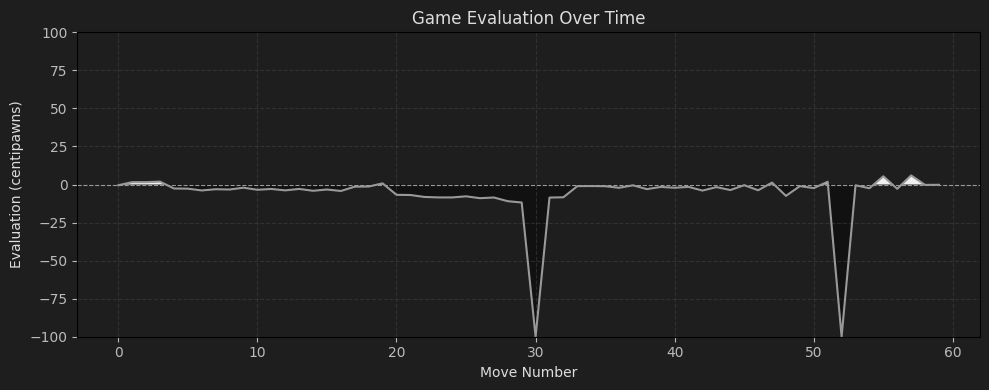

In [12]:
evaluator = Evaluation(engine, white_player=classifier, black_player=greedy)

scores = evaluator.play_game()
evaluator.draw_scores(scores)

evaluator.engine.board = chess.Board()

**Classifier with minimax** evaluation

Game has begun...
Game is finished.


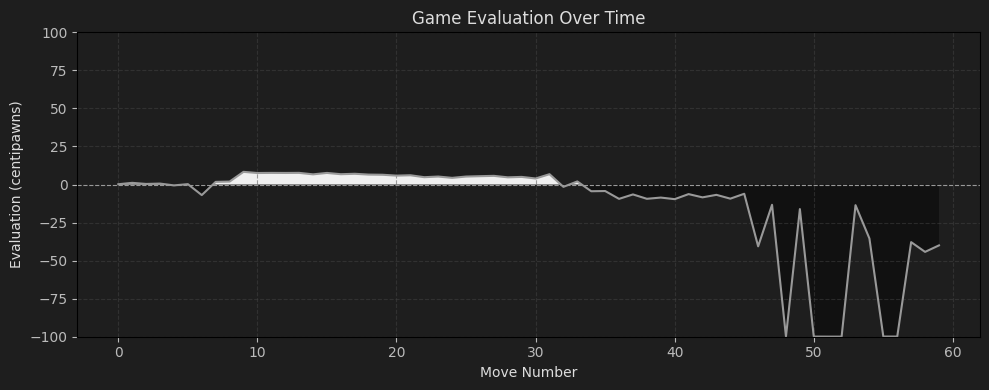

In [14]:
evaluator = Evaluation(engine, white_player=cl_minimax, black_player=greedy)

scores = evaluator.play_game()
evaluator.draw_scores(scores)

evaluator.engine.board = chess.Board()

**Random forest with minimax** evaluation

Game has begun...
Game is finished.


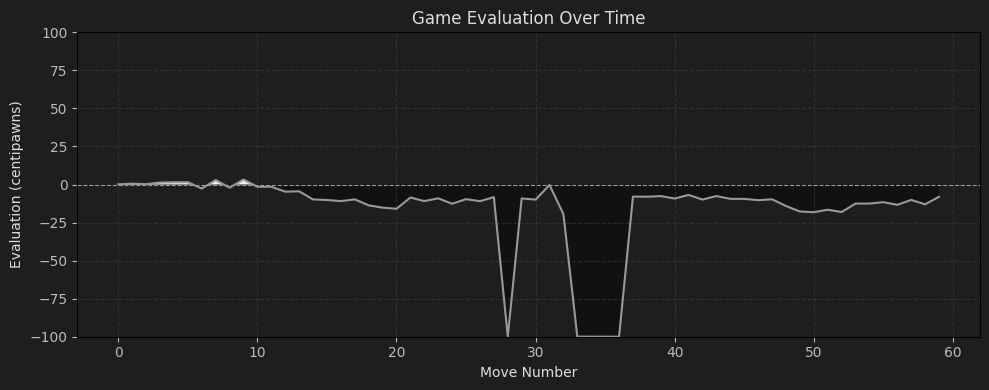

In [15]:
evaluator = Evaluation(engine, white_player=forest_minimax, black_player=greedy)

scores = evaluator.play_game()
evaluator.draw_scores(scores)

evaluator.engine.board = chess.Board()

We can see that for the three bots, it loses against a simple greedy bot. This is because a simple decision tree canot really "see" the board. That is to say it doesn't see where its pieces are attacked and even with a minimax algorithm whoch is supposed to select the moves which will give it the best score (decrease the material value of its opponent), it will not see those attacks.

#### 3.1 - One move evaluation

In this part, the bots are evaluated on their best move predictions. We give a dataset of 10000 positions, predict a move and if the move played improve the position for the player then it is a good move. The score given in % will be the proportion of predicted good move on the 10000 positions.

In [25]:
import pandas as pd
from tqdm import tqdm

In [34]:
test = pd.read_csv("data/data/test_positions.csv")[:1000]

In [19]:
def material_balance(board):
    """
    Simple material count: pawn=1, knight=3, bishop=3, rook=5, queen=9
    """
    piece_values = {
        chess.PAWN: 1,
        chess.KNIGHT: 3,
        chess.BISHOP: 3,
        chess.ROOK: 5,
        chess.QUEEN: 9,
        chess.KING: 0
    }

    score = 0
    for piece_type in piece_values:
        score += len(board.pieces(piece_type, chess.WHITE)) * piece_values[piece_type]
        score -= len(board.pieces(piece_type, chess.BLACK)) * piece_values[piece_type]
    return score

def center_control(board, color):
    """
    Count how many pieces control the center squares.
    """
    center_squares = [chess.D4, chess.D5, chess.E4, chess.E5]
    control = 0
    for square in center_squares:
        attackers = board.attackers(color, square)
        control += len(attackers)
    return control

def evaluate_single_move(board, move):
    """
    Evaluate if a move is good or not based on:
    - Material gain
    - Center control
    - Capturing a piece
    - Giving check
    """

    # Save current board state
    board_copy = board.copy()

    # Evaluate before move
    material_before = material_balance(board)
    center_before = center_control(board, board.turn)

    # Play the move
    board_copy.push(move)

    # Evaluate after move
    material_after = material_balance(board_copy)
    center_after = center_control(board_copy, not board.turn)  # After move, opponent's turn

    # Check if the move captured something
    captured_piece = board.piece_at(move.to_square)

    # Check if the move gives check
    gives_check = board_copy.is_check()

    # Criteria
    material_gain = (board.turn == chess.WHITE and material_after > material_before) or \
                    (board.turn == chess.BLACK and material_after < material_before)

    center_gain = center_after > center_before

    captured = captured_piece is not None

    # Final decision
    if material_gain or captured or gives_check or center_gain:
        return True
    else:
        return False

In [26]:
def evaluate_bot(bot, test_data):
    """
    Evaluate the bot on the 10,000 positions with a progress bar
    """
    good_moves = 0
    total_moves = len(test_data["fen"])

    for fen in tqdm(test_data["fen"], desc="Evaluating bot"):
        board = chess.Board(fen)
        bot.engine.board = board
        move = bot.predict()

        if move:
            classification = evaluate_single_move(board, move)

            if classification:
                good_moves += 1

    print(f"Percentage of good move predictions: {(good_moves / total_moves) * 100:.2f}%")

**Classifier with minimax** evaluation

In [35]:
evaluate_bot(classifier, test)

Evaluating bot: 100%|██████████| 1000/1000 [00:28<00:00, 35.62it/s]

Percentage of good move predictions: 58.70%


**Classifier with minimax** evaluation

In [36]:
evaluate_bot(cl_minimax, test)

Evaluating bot: 100%|██████████| 1000/1000 [03:51<00:00,  4.32it/s]

Percentage of good move predictions: 64.00%


**Random forest with minimax** evaluation

In [37]:
evaluate_bot(forest_minimax, test)

Evaluating bot: 100%|██████████| 1000/1000 [10:49<00:00,  1.54it/s]

Percentage of good move predictions: 64.80%
